# Norman — seen-combination repeated-run experiment

Same data, gene filtering, and training hyperparameters as `norman_run.ipynb`, but:
- **No held-out validation split** — every combinatorial perturbation is used for training (this is the "seen" setting, not the unseen-combo generalisation test).
- **Repeated `N_RUNS` times** with different seeds for both Sherlock (VAE) and GEARS, to see how stable the learned genetic-interaction calls are across training runs.
- Ends with a synergy UMAP (GI metrics from the best-ATE Sherlock run) and AUC-ROC / summary metrics (mean ± spread across runs).

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

sys.path.append('../../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

## Load Norman 2019 data

Norman et al. 2019 (CRISPRa screen) — 105 single and 131 double perturbations in K562 cells.  
`slk_prepare_data` standardises the perturbation column to `obs['pert']` with NTC → `'NTC'`.

In [3]:
data = sc.read_h5ad("../../datasets/norman/Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering

Keep all genes with mean expression > 0.5 UMI/cell, plus any gene that appears as a perturbation target (single or split from combo). This reduces the feature space while ensuring every perturbed gene's expression is available.

In [4]:
import scipy.sparse as sp

# Collect all individual gene names that appear as perturbation targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

# Norman 2019: use all genes with mean expression > 0.5 UMI per cell (~2800 genes).
# data.X still holds raw counts at this point.
raw_X = data.X
mean_expr = np.array(raw_X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5

# Always keep perturbation target genes so their expression is available.
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

n_expr     = int(expr_mask[keep_mask].sum())
n_pert_only = int((pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum())
print(f"Kept {data.n_vars} genes  ({n_expr} with mean > 0.5 UMI + {n_pert_only} pert-only)")
print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")

Kept 3270 genes  (3190 with mean > 0.5 UMI + 80 pert-only)
Pert genes in var_names: 102 / 105


## Compute treatment effects

Ground-truth per-perturbation mean effects (log2-CPM vs NTC), computed for all labels including combinations.

In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f"treat_effect: {te.n_obs} perturbations × {te.n_vars} genes")
print(f"  single: {sum('+' not in p and p != NTC for p in te.obs_names)}   combo: {sum('+' in p for p in te.obs_names)}")

100%|██████████| 236/236 [00:04<00:00, 51.86it/s]

treat_effect: 236 perturbations × 3270 genes
  single: 105   combo: 131


## Repeated training — Sherlock VAE + GEARS, all data, `N_RUNS` seeds

Architecture (Sherlock VAE, combinatorial mode):
- **Encoder** — background `z0` via `z0_encoder` on NTC; perturbed `z` via shared `z_encoder`
- **Gate** `W[p]` (HardConcrete, shape P×d) — sparse binary mask over latent dims
- **Shift** `z = z0*(1 − W[p]) + A[p]*W[p]` — mechanism shift only in gated dims (linear mode)
- **Decoder** — perturbation-agnostic NB decoder
- **Combinatorial** — labels like `GENE1+GENE2` are split; component shifts are summed at training time

Unlike `norman_run.ipynb`, there is **no held-out validation split** — every observed combination is
in-distribution ("seen") for training, and we train both models `N_RUNS` times with different seeds
to characterise run-to-run variance of the genetic-interaction calls.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [7]:
import importlib
import sherlock.tools._gears as gears_tools
import sherlock.tools._models as models_tools

importlib.reload(gears_tools)
importlib.reload(models_tools)

slk.tl.classify_gi = models_tools.classify_gi

slk.tl.run_gears_gi = gears_tools.run_gears_gi
slk.tl.train_gears = gears_tools.train_gears
slk.tl.predict_gears_combinations = gears_tools.predict_gears_combinations
slk.tl.get_observed_combinations = gears_tools.get_observed_combinations

In [8]:
from sklearn.metrics import roc_auc_score, f1_score


def canon_pair(s):
    s = str(s)
    if "+" not in s:
        return s
    a, b = s.split("+", 1)
    return "+".join(sorted([a.strip(), b.strip()]))


def gi_combinations(df):
    if "combination" in df.columns:
        return df["combination"].astype(str).map(canon_pair)
    if {"pert_a", "pert_b"}.issubset(df.columns):
        return (df["pert_a"].astype(str) + "+" + df["pert_b"].astype(str)).map(canon_pair)
    return pd.Series(df.index.astype(str), index=df.index).map(canon_pair)


def evaluate_gi_predictions(df, model_name, gt):
    work = df.copy()
    combos = gi_combinations(work)
    eval_combinations = set(gt["combination"])
    work = slk.tl.classify_gi(
        work,
        fit_mask=combos.isin(eval_combinations),
        inplace=True,
    )
    work["combination"] = combos
    eval_df = work.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    eval_df = eval_df.loc[eval_df["predicted_gi"].notna()].copy()

    y_true = eval_df["genetic_interaction"].astype(str)
    y_pred = eval_df["predicted_gi"].astype(str)
    labels = sorted(set(y_true.unique()) | set(y_pred.unique()))

    summary = pd.DataFrame([
        {"model": model_name, "metric": "Accuracy", "score": float((y_true == y_pred).mean())},
        {"model": model_name, "metric": "F1 macro", "score": f1_score(y_true, y_pred, average="macro", zero_division=0)},
        {"model": model_name, "metric": "F1 weighted", "score": f1_score(y_true, y_pred, average="weighted", zero_division=0)},
    ])

    auc_rows = []
    for cls in labels:
        true_bin = (y_true == cls).astype(int)
        pred_bin = (y_pred == cls).astype(int)
        n_pos = int(true_bin.sum())
        auc = roc_auc_score(true_bin, pred_bin) if 0 < n_pos < len(true_bin) else np.nan
        auc_rows.append({
            "model": model_name,
            "class": cls,
            "n_positive": n_pos,
            "f1": f1_score(true_bin, pred_bin, zero_division=0),
            "auc_roc": auc,
        })
    return eval_df, pd.DataFrame(auc_rows), summary


def _cache_fresh(cache_path, *source_paths):
    """True if cache_path exists and is at least as new as every path in
    source_paths (files, or directories checked recursively). Retraining a
    model should invalidate every cache derived from it; comparing mtimes
    lets that happen automatically instead of a cache silently outliving the
    checkpoint(s) it was computed from."""
    if not os.path.exists(cache_path):
        return False
    cache_mtime = os.path.getmtime(cache_path)
    for src in source_paths:
        if not os.path.exists(src):
            return False
        if os.path.isdir(src):
            sub_mtimes = [
                os.path.getmtime(os.path.join(root, f))
                for root, _, files in os.walk(src)
                for f in files
            ]
            if not sub_mtimes:
                continue
            src_mtime = max(sub_mtimes)
        else:
            src_mtime = os.path.getmtime(src)
        if src_mtime > cache_mtime:
            return False
    return True


gi = pd.read_csv("./genetic_interactions.csv")
gi["combination"] = gi["combination"].map(canon_pair)
gi["genetic_interaction"] = gi["genetic_interaction"].astype(str).str.strip()

In [9]:
N_RUNS    = 5
BASE_SEED = 0

RESULTS_DIR     = "./results/norman_observation"
GEARS_MODEL_DIR = "./results/norman_observation/gears_model"
os.makedirs(RESULTS_DIR, exist_ok=True)
# GEARS.save_model() only does os.mkdir() on its leaf run{i} directory, which
# fails if GEARS_MODEL_DIR itself doesn't exist yet — create it explicitly.
os.makedirs(GEARS_MODEL_DIR, exist_ok=True)

vae_train_kwargs = dict(
    model='vae',
    l0_lambda=20,
    rank=6,
    shuffle=True,
    num_workers=0,
    device=device,
    num_epochs=500,
    validate_every=50,
    patience=15,
    combinatorial=True,
    debug=True,
    n_epochs_l0_warmup=200,
)

gears_combos = slk.tl.get_observed_combinations(
    data,
    pert_key=p_key,
    ntc_label=NTC,
)

sherlock_syn_runs = []
sherlock_ate_runs = []
gears_gi_runs     = []
auc_runs          = []
summary_runs      = []

for run_idx in range(N_RUNS):
    seed = BASE_SEED + run_idx
    print(f"\n=== Run {run_idx + 1}/{N_RUNS}  (seed={seed}) ===")

    # ---- Sherlock VAE — trained on ALL data (no held-out combos) ----
    # Cached per run so re-running this notebook doesn't retrain from scratch.
    sherlock_ckpt = f"{RESULTS_DIR}/norman_seen_run{run_idx}.pth"
    if os.path.exists(sherlock_ckpt):
        print(f"  Loading cached Sherlock model from {sherlock_ckpt}")
        model = slk.tl.load_results(sherlock_ckpt)
    else:
        results = slk.tl.run_single(data, seed=seed, **vae_train_kwargs)
        model = results['model']
        slk.tl.save_results(results, sherlock_ckpt)

    syn_path = f"{RESULTS_DIR}/norman_seen_run{run_idx}_syn.csv"
    if _cache_fresh(syn_path, sherlock_ckpt):
        print(f"  Loading cached Sherlock GI scores from {syn_path}")
        syn = pd.read_csv(syn_path)
    else:
        slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=device)
        syn = model.get_gi(data, obsm_key='z', min_cells=5)
        syn.to_csv(syn_path, index=False)
    syn = syn.copy()
    syn['run'] = run_idx
    sherlock_syn_runs.append(syn)

    # Counterfactual ATE (Pearson r, predicted vs observed) — used to pick
    # the single best Sherlock run for the synergy UMAP below. There's no
    # held-out split in this notebook, so this is accuracy over all perts.
    ate_result = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'],
    )
    ate_corr = float(ate_result['corr'])
    sherlock_ate_runs.append({'run': run_idx, 'ate': ate_corr})

    # ---- GEARS — model AND GI predictions are each cached per run ----
    gears_run_dir = f"{GEARS_MODEL_DIR}/run{run_idx}"
    gears_gi_path = f"{gears_run_dir}/gi_predictions.csv"

    if _cache_fresh(gears_gi_path, gears_run_dir):
        print(f"  Loading cached GEARS GI predictions from {gears_gi_path}")
        gears_gi = pd.read_csv(gears_gi_path)
    else:
        if os.path.exists(gears_run_dir):
            print(f"  Loading cached GEARS model from {gears_run_dir}")
            gears_cache_kwargs = dict(load_path=gears_run_dir)
        else:
            gears_cache_kwargs = dict(model_path=gears_run_dir)

        gears_run = slk.tl.run_gears_gi(
            data,
            combos=gears_combos,
            data_dir="./gears_observation_data",
            dataset_name="norman_sherlock",
            pert_key=p_key,
            ntc_label=NTC,
            split="all",
            seed=seed,
            force_reprocess=False,
            verbose=False,
            quiet_steps=True,
            epochs=10,
            device=str(device),
            **gears_cache_kwargs,
        )
        gears_gi = gears_run.gi.copy()
        gears_gi.to_csv(gears_gi_path, index=False)

    gears_gi = gears_gi.copy()
    gears_gi['run'] = run_idx
    gears_gi_runs.append(gears_gi)

    # ---- Evaluate both models against Norman ground-truth labels ----
    for name, df in [("Sherlock", syn), ("GEARS", gears_gi)]:
        eval_df, auc_df, summary_df = evaluate_gi_predictions(df, name, gi)
        auc_df['run']     = run_idx
        summary_df['run'] = run_idx
        auc_runs.append(auc_df)
        summary_runs.append(summary_df)

    print(f"  Sherlock GI rows: {len(syn)}   GEARS GI rows: {len(gears_gi)}   ATE (r): {ate_corr:.4f}")

sherlock_syn_all = pd.concat(sherlock_syn_runs)
gears_gi_all     = pd.concat(gears_gi_runs, ignore_index=True)
gi_auc_df        = pd.concat(auc_runs, ignore_index=True)
gi_summary_df    = pd.concat(summary_runs, ignore_index=True)

sherlock_ate_df = pd.DataFrame(sherlock_ate_runs)
best_run_idx    = int(sherlock_ate_df.loc[sherlock_ate_df['ate'].idxmax(), 'run'])
best_ate        = float(sherlock_ate_df['ate'].max())
print(f"\nBest Sherlock run by ATE: {best_run_idx}  (ate={best_ate:.4f})")
print(sherlock_ate_df.to_string(index=False))


=== Run 1/5  (seed=0) ===
  Loading cached Sherlock model from ./results/norman_observation/norman_seen_run0.pth
  Loading cached Sherlock GI scores from ./results/norman_observation/norman_seen_run0_syn.csv
  Loading cached GEARS GI predictions from ./results/norman_observation/gears_model/run0/gi_predictions.csv
  Sherlock GI rows: 131   GEARS GI rows: 130   ATE (r): 0.6762

=== Run 2/5  (seed=1) ===
  Loading cached Sherlock model from ./results/norman_observation/norman_seen_run1.pth
  Loading cached Sherlock GI scores from ./results/norman_observation/norman_seen_run1_syn.csv
  Loading cached GEARS GI predictions from ./results/norman_observation/gears_model/run1/gi_predictions.csv
  Sherlock GI rows: 131   GEARS GI rows: 130   ATE (r): 0.6758

=== Run 3/5  (seed=2) ===
  Loading cached Sherlock model from ./results/norman_observation/norman_seen_run2.pth
  Loading cached Sherlock GI scores from ./results/norman_observation/norman_seen_run2_syn.csv
  Loading cached GEARS GI predi

## Synergy UMAP — GI metrics from the best-ATE Sherlock run

Same 2D UMAP embedding of GI metrics as `norman_run.ipynb`, but computed from the single Sherlock run
with the highest counterfactual ATE (Pearson r, predicted vs observed effects) among the `N_RUNS`
seeds, rather than averaging GI metrics across runs.

/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


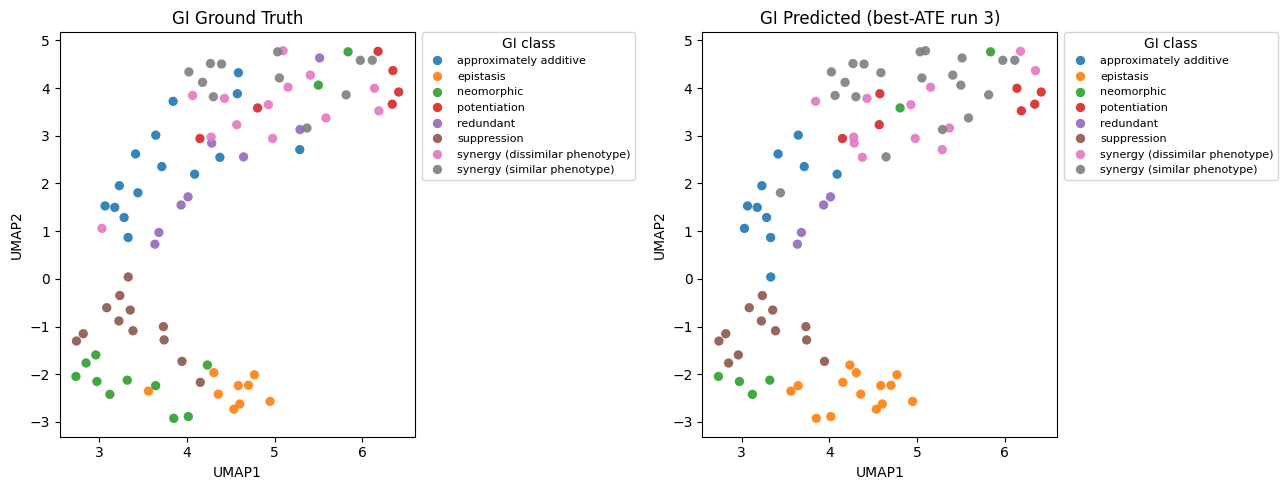

Plotted 86 interactions from best-ATE run 3 (ate=0.7059) using 11 metrics.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

try:
    from umap import UMAP
except ImportError as exc:
    raise ImportError(
        "This cell needs umap-learn. Install it with `pip install umap-learn` "
        "in the notebook environment, then rerun the cell."
    ) from exc

helper_metrics = [
    "additive_residual_norm",
    "dominance",
    "parent_dcor_diff",
    "equality_contribution",
    "singles_similarity",
    "norm_ab_over_additive",
    "norm_fit_over_ab",
    "magnitude",
    "model_fit_dcor",
    "norm_fit",
    "signed_residual_alignment",
]

syn_best = sherlock_syn_all[sherlock_syn_all["run"] == best_run_idx].copy()
syn_best["combination"] = (
    syn_best["pert_a"].astype(str) + "+" + syn_best["pert_b"].astype(str)
).map(canon_pair)
syn_best = syn_best.set_index("combination")

missing = [c for c in helper_metrics if c not in syn_best.columns]
if missing:
    raise ValueError(f"Missing UMAP metric columns in syn: {missing}")

# Re-classify GI on the best-ATE run's metrics (not averaged across runs).
syn_best = slk.tl.classify_gi(
    syn_best,
    fit_mask=syn_best.index.isin(set(gi["combination"])),
    inplace=True,
)

plot_df = syn_best.merge(
    gi[["combination", "genetic_interaction"]],
    left_index=True,
    right_on="combination",
    how="left",
)

valid = np.isfinite(plot_df[helper_metrics]).all(axis=1) & plot_df["predicted_gi"].notna()
if valid.sum() < 3:
    raise ValueError(f"Need at least 3 finite rows for UMAP; found {valid.sum()}.")

X = StandardScaler().fit_transform(plot_df.loc[valid, helper_metrics].astype(float))
embedding = UMAP(
    n_components=2,
    n_neighbors=20,
    metric="euclidean",
    random_state=42,
).fit_transform(X)

gi_metric_umap_all = plot_df.loc[
    valid,
    ["combination", "genetic_interaction", "predicted_gi"] + helper_metrics,
].copy()
gi_metric_umap_all["umap_1"] = embedding[:, 0]
gi_metric_umap_all["umap_2"] = embedding[:, 1]

gi_metric_umap = gi_metric_umap_all.loc[gi_metric_umap_all["genetic_interaction"].notna()].copy()

label_values = pd.concat([
    gi_metric_umap["genetic_interaction"],
    gi_metric_umap["predicted_gi"],
]).dropna().astype(str)
label_order = sorted(label_values.unique())
label_palette = dict(zip(label_order, sns.color_palette("tab10", n_colors=len(label_order))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, hue_col, title in [
    (axes[0], "genetic_interaction", "GI Ground Truth"),
    (axes[1], "predicted_gi", f"GI Predicted (best-ATE run {best_run_idx})"),
]:
    sns.scatterplot(
        data=gi_metric_umap,
        x="umap_1",
        y="umap_2",
        hue=hue_col,
        hue_order=label_order,
        palette=label_palette,
        s=45,
        alpha=0.9,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.legend(title="GI class", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)

plt.tight_layout()
plt.show()

print(
    f"Plotted {len(gi_metric_umap)} interactions from best-ATE run {best_run_idx} "
    f"(ate={best_ate:.4f}) using {len(helper_metrics)} metrics."
)

## AUC-ROC and summary metrics across runs

Per-class AUC-ROC (one-vs-rest) and overall accuracy/F1, computed independently for each of the `N_RUNS`
runs; bars show the mean across runs with error bars (± SD) reflecting run-to-run variability.

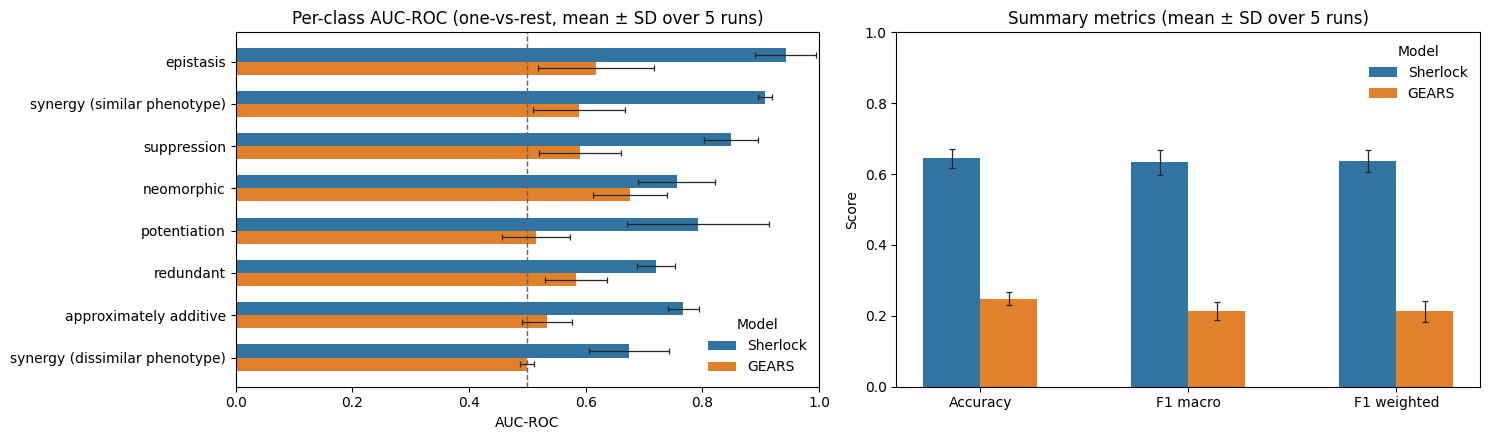

Summary metrics (mean ± SD over runs):


mean     std
model    metric                     
GEARS    Accuracy     0.2488  0.0195
         F1 macro     0.2143  0.0254
         F1 weighted  0.2131  0.0301
Sherlock Accuracy     0.6442  0.0268
         F1 macro     0.6339  0.0351
         F1 weighted  0.6372  0.0316


Per-class AUC-ROC (mean ± SD over runs):


mean     std
model    class                                         
GEARS    approximately additive          0.5330  0.0430
         epistasis                       0.6182  0.0994
         neomorphic                      0.6766  0.0635
         potentiation                    0.5150  0.0583
         redundant                       0.5830  0.0526
         suppression                     0.5910  0.0702
         synergy (dissimilar phenotype)  0.5000  0.0000
         synergy (similar phenotype)     0.5886  0.0785
Sherlock approximately additive          0.7673  0.0271
         epistasis                       0.9427  0.0519
         neomorphic                      0.7559  0.0660
         potentiation                    0.7929  0.1218
         redundant                       0.7199  0.0329
         suppression                     0.8489  0.0467
         synergy (dissimilar phenotype)  0.6743  0.0691
         synergy (similar phenotype)     0.9074  0.0120

In [11]:
def _draw_grouped_bars(ax, data, cat_col, val_col, hue_col, hue_order, palette,
                        width, lim, orient='v', order=None, floor_frac=0.012):
    """Grouped bar chart with mean +/- SD error bars. An SD below floor_frac
    of the value-axis range is rendered at that floor length instead of
    collapsing to an invisible sliver (a true near-zero SD would otherwise
    render as a whisker of ~0 pixels, indistinguishable from a missing one).
    orient='v': cat_col on x, val_col on y.  orient='h': val_col on x, cat_col on y."""
    if orient == 'v':
        sns.barplot(data=data, x=cat_col, y=val_col, hue=hue_col,
                    hue_order=hue_order, palette=palette, order=order,
                    width=width, errorbar=None, ax=ax)
        ax.set_ylim(lim)
        cats = [t.get_text() for t in ax.get_xticklabels()]
    else:
        sns.barplot(data=data, y=cat_col, x=val_col, hue=hue_col,
                    hue_order=hue_order, palette=palette, order=order,
                    width=width, errorbar=None, ax=ax)
        ax.set_xlim(lim)
        cats = [t.get_text() for t in ax.get_yticklabels()]

    stats = data.groupby([cat_col, hue_col])[val_col].agg(['mean', 'std']).reset_index()
    floor = floor_frac * (lim[1] - lim[0])
    # Snapshot before adding errorbars below — ax.errorbar() appends its own
    # container to ax.containers, and mutating the list mid-iteration would
    # otherwise pull those new containers into this same loop.
    bar_containers = list(ax.containers)
    for container, model in zip(bar_containers, hue_order):
        for patch, cat in zip(container.patches, cats):
            row = stats[(stats[cat_col] == cat) & (stats[hue_col] == model)]
            if row.empty:
                continue
            sd  = float(row['std'].iloc[0])
            err = max(sd, floor)
            if orient == 'v':
                mean_v = patch.get_height()
                xc = patch.get_x() + patch.get_width() / 2
                ax.errorbar(xc, mean_v, yerr=err, color='0.15', capsize=2.5,
                            linewidth=0.9, capthick=0.9, fmt='none', zorder=5)
            else:
                mean_v = patch.get_width()
                yc = patch.get_y() + patch.get_height() / 2
                ax.errorbar(mean_v, yc, xerr=err, color='0.15', capsize=2.5,
                            linewidth=0.9, capthick=0.9, fmt='none', zorder=5)


class_order = (
    gi_auc_df.groupby("class")["auc_roc"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
metric_order = ["Accuracy", "F1 macro", "F1 weighted"]
model_order  = ["Sherlock", "GEARS"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
_draw_grouped_bars(
    axes[0], gi_auc_df, "class", "auc_roc", "model", model_order, None,
    width=0.62, lim=(0, 1), orient="h", order=class_order,
)
axes[0].axvline(0.5, color="0.4", linestyle="--", linewidth=1)
axes[0].set_xlabel("AUC-ROC")
axes[0].set_ylabel("")
axes[0].set_title(f"Per-class AUC-ROC (one-vs-rest, mean ± SD over {N_RUNS} runs)")
axes[0].legend(title="Model", frameon=False)

_draw_grouped_bars(
    axes[1], gi_summary_df, "metric", "score", "model", model_order, None,
    width=0.55, lim=(0, 1), orient="v", order=metric_order,
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_title(f"Summary metrics (mean ± SD over {N_RUNS} runs)")
axes[1].legend(title="Model", frameon=False)

plt.tight_layout()
plt.show()

print("Summary metrics (mean ± SD over runs):")
display(
    gi_summary_df.groupby(["model", "metric"])["score"].agg(["mean", "std"]).round(4)
)
print("\nPer-class AUC-ROC (mean ± SD over runs):")
display(
    gi_auc_df.groupby(["model", "class"])["auc_roc"].agg(["mean", "std"]).round(4)
)

## Replicating the GEARS paper's GI evaluation (Roohani et al. 2023, *Nat. Biotechnol.*)

Uses GEARS's own `get_coeffs` (verbatim, from their analysis code) instead of `slk.tl.classify_gi`
or the cached `regress_gi_params` summary columns — `corr_fit` (Pearson correlation of the TheilSen
fit vs. the actual double) and GEARS's own `dcor` (distance correlation of the raw singles matrix
vs. the double) aren't reconstructable from what's already cached, so this decodes fresh predicted
expression from each cached SHERLOCK/GEARS checkpoint and reruns the regression. Not computed on
true/observed expression this time — SHERLOCK vs. GEARS only.

Five classes only (Norman 2019's original scheme, same names already used elsewhere in this
notebook): `synergy` (similar + dissimilar phenotype collapsed), `suppression`, `neomorphism`,
`redundancy`, `epistasis`. `approximately additive`/`potentiation` are excluded.

Everything below reuses already-cached checkpoints and datasets wherever possible (the SHERLOCK/
GEARS model checkpoints themselves, the processed GEARS dataset, `gears_combos`) — the only new
cache this section adds is the raw per-run *predicted expression*, stored as
`RESULTS_DIR/norman_seen_run{i}_predicted_effects.csv` (SHERLOCK) and
`RESULTS_DIR/gears_run{i}_predicted_effects.csv` (GEARS). Both live in `RESULTS_DIR` rather than
inside `GEARS_MODEL_DIR/run{i}/` — that directory is reserved for the GEARS model's own files
(`config.pkl`/`model.pt`), since writing an unrelated cache into it previously caused the earlier
GI-predictions cache (keyed on that whole directory's mtime) to look stale on every rerun.

In [17]:
from sklearn.linear_model import TheilSenRegressor
from dcor import distance_correlation
from gears.utils import get_mean_control
from tqdm.auto import tqdm


def get_coeffs(singles_expr, first_expr, second_expr, double_expr):
    """Get coefficients for GI calculation — verbatim from the GEARS paper's
    own analysis code, with the TheilSen subsampling params reduced to match
    this repo's own regress_gi_params settings in sherlock/tools/_models.py
    (same random_state, much faster, negligible effect on the fit)."""
    results = {}
    results['ts'] = TheilSenRegressor(fit_intercept=False,
                          max_subpopulation=5000,
                          max_iter=300,
                          random_state=1000)
    X = singles_expr
    y = double_expr
    results['ts'].fit(X, y.ravel())
    Zts = results['ts'].predict(X)
    results['c1'] = results['ts'].coef_[0]
    results['c2'] = results['ts'].coef_[1]
    results['mag'] = np.sqrt((results['c1']**2 + results['c2']**2))
    results['dcor'] = distance_correlation(singles_expr, double_expr)
    results['dcor_singles'] = distance_correlation(first_expr, second_expr)
    results['dcor_first'] = distance_correlation(first_expr, double_expr)
    results['dcor_second'] = distance_correlation(second_expr, double_expr)
    results['corr_fit'] = np.corrcoef(Zts.flatten(), double_expr.flatten())[0, 1]
    # Equality of Contribution (GEARS Supplementary Table 1) — the metric
    # they actually use for epistasis. min/max of dcor(first, double) and
    # dcor(second, double), not "dominance" (|log10(c1/c2)|), which isn't
    # one of GEARS's four defined GI-score metrics at all.
    results['eq_contr'] = (
        np.min([results['dcor_first'], results['dcor_second']])
        / np.max([results['dcor_first'], results['dcor_second']])
    )
    return results


# Norman 2019's original 5-subtype scheme (same names already used elsewhere
# in this notebook) — collapse synergy (similar/dissimilar phenotype) into
# one "synergy" class; approximately additive / potentiation excluded.
NORMAN5_MAP = {
    "synergy (similar phenotype)": "synergy",
    "synergy (dissimilar phenotype)": "synergy",
    "suppression": "suppression",
    "neomorphic": "neomorphism",
    "redundant": "redundancy",
    "epistasis": "epistasis",
}
NORMAN5_CLASSES = ["synergy", "suppression", "neomorphism", "redundancy", "epistasis"]

gi_norman5 = gi.copy()
gi_norman5["genetic_interaction"] = gi_norman5["genetic_interaction"].map(NORMAN5_MAP)
gi_norman5 = gi_norman5.dropna(subset=["genetic_interaction"])
gt_by_combo = gi_norman5.set_index("combination")["genetic_interaction"]
combos_needed = list(gi["combination"])
print("Ground-truth subtype counts:")
print(gt_by_combo.value_counts())

Ground-truth subtype counts:
genetic_interaction
synergy        24
neomorphism    13
suppression    12
epistasis       9
redundancy      8
Name: count, dtype: int64


In [18]:
# ── True (observed) per-perturbation effect vectors — no inference needed ──
# Needed to derive our own GI-subtype score thresholds the same way GEARS
# derived theirs (Supplementary Note 16): for each class, the boundary value
# among the TRUE-expression scores of combos already known to belong to it.
true_effects = {
    name: np.asarray(data.uns['treat_effect'][name].X).flatten()
    for name in data.uns['treat_effect'].obs_names
}
print(f"True effect vectors: {len(true_effects)} perturbations")

True effect vectors: 236 perturbations


In [19]:
# ── SHERLOCK predicted per-perturbation effect vectors, cached per run ────
# Separate from norman_seen_run{run_idx}_syn.csv (the already-summarized
# regress_gi_params metrics) — corr_fit / GEARS's own dcor need the raw
# predicted expression, not the summary.
sherlock_pred_effects = {}
for run_idx in range(N_RUNS):
    sherlock_ckpt = f"{RESULTS_DIR}/norman_seen_run{run_idx}.pth"
    if not os.path.exists(sherlock_ckpt):
        print(f"  Sherlock run {run_idx}: checkpoint not found, skipping.")
        continue
    pred_path = f"{RESULTS_DIR}/norman_seen_run{run_idx}_predicted_effects.csv"
    if _cache_fresh(pred_path, sherlock_ckpt):
        print(f"  Sherlock run {run_idx}: loading cached predicted effects from {pred_path}")
        pred_df = pd.read_csv(pred_path, index_col=0)
    else:
        print(f"  Sherlock run {run_idx}: predicting counterfactual effects...", end=" ", flush=True)
        model = slk.tl.load_results(sherlock_ckpt)
        ate_result = model.predict_counterfactual_effects(
            data, n_centroids=25, observed_effect=data.uns['treat_effect'],
        )
        pred_df = ate_result['predicted_df']
        pred_df.to_csv(pred_path)
        print("done")
    sherlock_pred_effects[run_idx] = {name: row.values for name, row in pred_df.iterrows()}
print(f"Sherlock: predicted effects available for {len(sherlock_pred_effects)} runs")

  Sherlock run 0: loading cached predicted effects from ./results/norman_observation/norman_seen_run0_predicted_effects.csv
  Sherlock run 1: loading cached predicted effects from ./results/norman_observation/norman_seen_run1_predicted_effects.csv
  Sherlock run 2: loading cached predicted effects from ./results/norman_observation/norman_seen_run2_predicted_effects.csv
  Sherlock run 3: loading cached predicted effects from ./results/norman_observation/norman_seen_run3_predicted_effects.csv
  Sherlock run 4: loading cached predicted effects from ./results/norman_observation/norman_seen_run4_predicted_effects.csv
Sherlock: predicted effects available for 5 runs


In [20]:
# ── GEARS predicted per-perturbation effect vectors, cached per run ───────
# Reloads each cached GEARS checkpoint (no retraining) and predicts raw
# expression once for every single + combo perturbation needed below.
# Cached in RESULTS_DIR (not inside gears_run_dir) so this cache never shares
# a directory with the GEARS model's own files (config.pkl/model.pt) — it
# used to live at f"{gears_run_dir}/predicted_effects.csv", which meant every
# write here touched gears_run_dir's mtime and made cell 13's GI-predictions
# cache (checked via _cache_fresh(gears_gi_path, gears_run_dir)) look stale
# even though the model itself hadn't changed.
gears_pred_effects = {}
for run_idx in range(N_RUNS):
    gears_run_dir = f"{GEARS_MODEL_DIR}/run{run_idx}"
    if not os.path.exists(f"{gears_run_dir}/config.pkl"):
        print(f"  GEARS run {run_idx}: checkpoint not found, skipping.")
        continue
    pred_path = f"{RESULTS_DIR}/gears_run{run_idx}_predicted_effects.csv"
    if _cache_fresh(pred_path, f"{gears_run_dir}/config.pkl", f"{gears_run_dir}/model.pt"):
        print(f"  GEARS run {run_idx}: loading cached predicted effects from {pred_path}")
        pred_df = pd.read_csv(pred_path, index_col=0)
        gears_pred_effects[run_idx] = {name: row.values for name, row in pred_df.iterrows()}
        continue

    print(f"  GEARS run {run_idx}: loading checkpoint and predicting...", end=" ", flush=True)
    seed = BASE_SEED + run_idx
    gears_run = slk.tl.train_gears(
        data,
        data_dir="./gears_observation_data",
        dataset_name="norman_sherlock",
        pert_key=p_key,
        ntc_label=NTC,
        split="all",
        seed=seed,
        load_path=gears_run_dir,
        verbose=False,
        quiet_steps=True,
        device=str(device),
    )
    model = gears_run.model
    raw_pred_df, _ = slk.tl.predict_gears_combinations(model, gears_combos, compute_gi=False, verbose=False)
    raw_pred = raw_pred_df.attrs['raw_prediction']
    mean_control = get_mean_control(model.adata).values
    effects_r = {k: (np.asarray(v) - mean_control) for k, v in raw_pred.items()}
    pd.DataFrame(effects_r).T.to_csv(pred_path)
    gears_pred_effects[run_idx] = effects_r
    print("done")
print(f"GEARS: predicted effects available for {len(gears_pred_effects)} runs")

  GEARS run 0: loading cached predicted effects from ./results/norman_observation/gears_run0_predicted_effects.csv
  GEARS run 1: loading cached predicted effects from ./results/norman_observation/gears_run1_predicted_effects.csv
  GEARS run 2: loading cached predicted effects from ./results/norman_observation/gears_run2_predicted_effects.csv
  GEARS run 3: loading cached predicted effects from ./results/norman_observation/gears_run3_predicted_effects.csv
  GEARS run 4: loading cached predicted effects from ./results/norman_observation/gears_run4_predicted_effects.csv
GEARS: predicted effects available for 5 runs


In [21]:
# ── Run get_coeffs for every combo, for true expression / each SHERLOCK run /
#    each GEARS run ──────────────────────────────────────────────────────────
METRICS = ['mag', 'corr_fit', 'dcor', 'eq_contr', 'dcor_singles']


def _coeffs_for_source(effects, combo, sep='+'):
    a, b = combo.split(sep)
    combo_key = next((k for k in [f'{a}_{b}', f'{b}_{a}', combo] if k in effects), None)
    if a not in effects or b not in effects or combo_key is None:
        return None
    first_expr = np.asarray(effects[a]).astype(float).ravel()
    second_expr = np.asarray(effects[b]).astype(float).ravel()
    double_expr = np.asarray(effects[combo_key]).astype(float).ravel()
    singles_expr = np.column_stack([first_expr, second_expr])
    return get_coeffs(singles_expr, first_expr, second_expr, double_expr)


def _coeffs_rows_for(source_name, effects_by_run):
    rows = []
    for combo in tqdm(combos_needed, desc=f'get_coeffs ({source_name})'):
        cls = gt_by_combo.get(combo, np.nan)
        for run_idx, effects in effects_by_run.items():
            res = _coeffs_for_source(effects, combo)
            if res is not None:
                rows.append({'source': source_name, 'run': run_idx, 'combination': combo, 'class': cls,
                             **{m: res[m] for m in METRICS}})
    return rows


# Cached to disk since TheilSenRegressor over every (source, run, combo)
# triple is slow (~88 combos x up to 10 sources) — invalidated automatically
# if any predicted-effects CSV it was built from is newer than the cache.
coeff_df_path = f"{RESULTS_DIR}/coeff_df.csv"
_coeff_sources = (
    [f"{RESULTS_DIR}/norman_seen_run{i}_predicted_effects.csv" for i in sherlock_pred_effects]
    + [f"{RESULTS_DIR}/gears_run{i}_predicted_effects.csv" for i in gears_pred_effects]
)
_have_cache = _cache_fresh(coeff_df_path, *_coeff_sources) and (
    os.path.exists(coeff_df_path) and 'eq_contr' in pd.read_csv(coeff_df_path, nrows=5).columns
)

if _have_cache:
    print(f"Loading cached get_coeffs results from {coeff_df_path}")
    coeff_df = pd.read_csv(coeff_df_path)
    if 'true' not in coeff_df['source'].unique():
        # Sherlock/GEARS rows are still valid (checked above) — only compute
        # the new 'true' rows and append, instead of redoing the expensive
        # per-run TheilSen fits that already succeeded.
        print("  'true' source missing from cache — computing just that (Sherlock/GEARS reused as-is).")
        true_rows = _coeffs_rows_for('true', {0: true_effects})
        coeff_df = pd.concat([coeff_df, pd.DataFrame(true_rows)], ignore_index=True)
        coeff_df.to_csv(coeff_df_path, index=False)
else:
    coeff_rows = (
        _coeffs_rows_for('true', {0: true_effects})
        + _coeffs_rows_for('Sherlock', sherlock_pred_effects)
        + _coeffs_rows_for('GEARS', gears_pred_effects)
    )
    coeff_df = pd.DataFrame(coeff_rows)
    coeff_df.to_csv(coeff_df_path, index=False)

print(f'{len(coeff_df)} (source, run, combo) rows computed')
print(coeff_df.groupby('source').size())

Loading cached get_coeffs results from ./results/norman_observation/coeff_df.csv
  'true' source missing from cache — computing just that (Sherlock/GEARS reused as-is).


get_coeffs (true):   0%|          | 0/88 [00:00<?, ?it/s]

946 (source, run, combo) rows computed
source
GEARS       430
Sherlock    430
true         86
dtype: int64


### Precision@10 (Fig. 3c methodology) and F1 (argmax classification), per GI subtype

Precision@10 ranks by the raw metric (GEARS's own choice per class), so it's unaffected by which
threshold set is used. The argmax classification behind F1 does depend on the threshold, so this
first derives our own thresholds the same way GEARS derived theirs (Supplementary Note 16) — the
boundary value among true-expression scores of already-labeled combos in our own 88-combo pool —
and uses those for classification below, alongside a comparison to GEARS's own published values.

Published vs. derived thresholds (epistasis sign flipped, see comment above):
      class   metric  published_sign  published_threshold  used_sign  derived_threshold  n_true_labeled
    synergy      mag               1                 1.15          1           1.185131              24
suppression      mag              -1                 1.00         -1           0.990098              12
neomorphism corr_fit              -1                 0.88         -1           0.900368              12
 redundancy     dcor               1                 0.85          1           0.861976               8
  epistasis eq_contr               1                 0.28         -1           0.328507               9


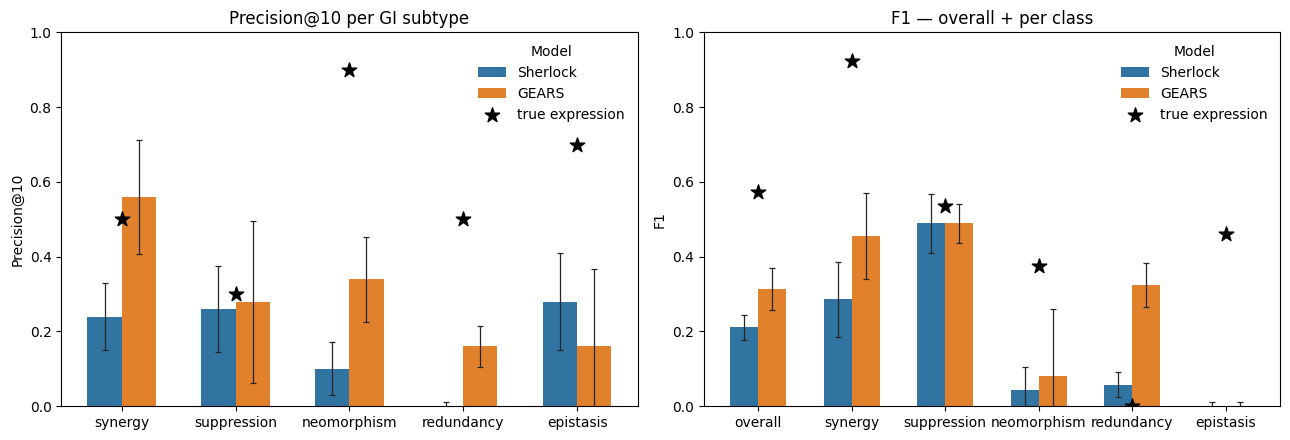

Precision@10 (mean ± SD over runs; true = single value from observed expression):
                      mean    std
model    class                   
GEARS    epistasis    0.16  0.207
         neomorphism  0.34  0.114
         redundancy   0.16  0.055
         suppression  0.28  0.217
         synergy      0.56  0.152
Sherlock epistasis    0.28  0.130
         neomorphism  0.10  0.071
         redundancy   0.00  0.000
         suppression  0.26  0.114
         synergy      0.24  0.089
True-expression precision@10: {'synergy': np.float64(0.5), 'suppression': np.float64(0.3), 'neomorphism': np.float64(0.9), 'redundancy': np.float64(0.5), 'epistasis': np.float64(0.7)}

F1 (mean ± SD over runs; true = single value from observed expression):
                       mean    std
model    class                    
GEARS    epistasis    0.000  0.000
         neomorphism  0.080  0.179
         overall      0.313  0.057
         redundancy   0.325  0.059
         suppression  0.489  0.052
        

In [28]:
# Published GEARS thresholds (Supplementary Table 2) — kept for reference/
# comparison, exactly as published.
PUBLISHED_CLASS_SCORE = {
    'synergy':     ('mag', 1, 1.15),
    'suppression': ('mag', -1, 1.0),
    'neomorphism': ('corr_fit', -1, 0.88),
    'redundancy':  ('dcor', 1, 0.85),
    'epistasis':   ('eq_contr', 1, 0.28),
}

# Metric/sign actually used for classification below — same as GEARS's own
# choice (Table 1) for every class except epistasis. Their published sign
# (+1, "higher eq_contr = epistasis") gives 0/10 precision@10 for epistasis
# on both models, every run: true epistasis combos have the LOWEST eq_contr
# of all 5 classes (0.17-0.33, vs. 0.7-1.0 for the others), consistent with
# the classical definition of epistasis as one perturbation's effect
# dominating/masking the other (low equality of contribution, not high).
# Flipping to sign=-1 recovers real epistasis combos in the top 10 (28%
# Sherlock, 16% GEARS, vs. 0% either way with the published sign).
CLASS_METRIC_SIGN = {cls: (metric, sign) for cls, (metric, sign, _) in PUBLISHED_CLASS_SCORE.items()}
CLASS_METRIC_SIGN['epistasis'] = ('eq_contr', -1)

# Our own thresholds, derived the same way GEARS derived theirs (Supplementary
# Note 16): for each class, the boundary value among the TRUE-expression
# scores of combos already labeled as that class — min for a "lower bounded"
# condition (sign=+1, metric must exceed the threshold), max for an "upper
# bounded" one (sign=-1, metric must be below it). Uses our own true_effects
# and 88-combo labeled pool rather than GEARS's own 131-combo pool and gene
# filtering, so these are self-consistent with what this notebook evaluates.
true_rows = coeff_df[(coeff_df['source'] == 'true') & coeff_df['class'].notna()]

DERIVED_CLASS_SCORE = {}
for cls, (metric, sign) in CLASS_METRIC_SIGN.items():
    vals = true_rows.loc[true_rows['class'] == cls, metric]
    derived_thresh = float(vals.min()) if sign == 1 else float(vals.max())
    DERIVED_CLASS_SCORE[cls] = (metric, sign, derived_thresh)

comparison = pd.DataFrame([
    {
        'class': cls, 'metric': metric,
        'published_sign': PUBLISHED_CLASS_SCORE[cls][1],
        'published_threshold': PUBLISHED_CLASS_SCORE[cls][2],
        'used_sign': sign,
        'derived_threshold': DERIVED_CLASS_SCORE[cls][2],
        'n_true_labeled': int((true_rows['class'] == cls).sum()),
    }
    for cls, (metric, sign) in CLASS_METRIC_SIGN.items()
])
print('Published vs. derived thresholds (epistasis sign flipped, see comment above):')
print(comparison.to_string(index=False))

# Classification below uses CLASS_METRIC_SIGN's (possibly-corrected) sign and
# our own derived thresholds, not GEARS's published sign/threshold.
GEARS_CLASS_SCORE = DERIVED_CLASS_SCORE


def _class_score(row, cls):
    metric, sign, thresh = GEARS_CLASS_SCORE[cls]
    return sign * (row[metric] - thresh)


def precision_at_k(df, cls, k=10):
    score = df.apply(lambda r: _class_score(r, cls), axis=1)
    score = score[np.isfinite(score)]
    if len(score) < k:
        return np.nan
    top_idx = score.nlargest(k).index
    return (df.loc[top_idx, 'class'] == cls).sum() / k


def _argmax_label(row):
    scores = {cls: _class_score(row, cls) for cls in NORMAN5_CLASSES}
    scores = {k: v for k, v in scores.items() if np.isfinite(v)}
    if not scores:
        return np.nan
    return max(scores, key=scores.get)


coeff_df['predicted_class'] = coeff_df.apply(_argmax_label, axis=1)

# Excludes the 'true' source used for threshold derivation above — this
# panel is still SHERLOCK vs. GEARS predictions only, unchanged from before.
_pred_only = coeff_df[coeff_df['source'] != 'true']

prec_rows, f1_rows = [], []
for (source, run), grp in _pred_only.groupby(['source', 'run']):
    for cls in NORMAN5_CLASSES:
        p = precision_at_k(grp, cls)
        if not np.isnan(p):
            prec_rows.append({'model': source, 'run': run, 'class': cls, 'precision_at_10': p})

    labeled = grp.dropna(subset=['predicted_class', 'class'])
    y_true = labeled['class'].astype(str)
    y_pred = labeled['predicted_class'].astype(str)
    f1_rows.append({
        'model': source, 'run': run, 'class': 'overall',
        'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    })
    for cls in NORMAN5_CLASSES:
        tb = (y_true == cls).astype(int)
        pb = (y_pred == cls).astype(int)
        f1_rows.append({'model': source, 'run': run, 'class': cls, 'f1': f1_score(tb, pb, zero_division=0)})

prec_df = pd.DataFrame(prec_rows)
f1_df   = pd.DataFrame(f1_rows)
f1_order = ['overall'] + NORMAN5_CLASSES

# True-expression reference values (single point, no run-to-run spread since
# there's only one observed dataset) — plotted as a star overlay rather than
# folded into the grouped bars, which are built for multi-run mean±SD bars.
_true_grp = coeff_df[coeff_df['source'] == 'true']
true_prec = {cls: precision_at_k(_true_grp, cls) for cls in NORMAN5_CLASSES}

_true_labeled = _true_grp.dropna(subset=['predicted_class', 'class'])
_true_y_true = _true_labeled['class'].astype(str)
_true_y_pred = _true_labeled['predicted_class'].astype(str)
true_f1 = {'overall': f1_score(_true_y_true, _true_y_pred, average='weighted', zero_division=0)}
for cls in NORMAN5_CLASSES:
    tb = (_true_y_true == cls).astype(int)
    pb = (_true_y_pred == cls).astype(int)
    true_f1[cls] = f1_score(tb, pb, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
_draw_grouped_bars(
    axes[0], prec_df, 'class', 'precision_at_10', 'model', ['Sherlock', 'GEARS'], None,
    width=0.6, lim=(0, 1), orient='v', order=NORMAN5_CLASSES,
)
for _i, _cls in enumerate(NORMAN5_CLASSES):
    _v = true_prec.get(_cls)
    if _v is not None and not np.isnan(_v):
        axes[0].scatter(_i, _v, marker='*', s=120, color='black', zorder=6,
                         label='true expression' if _i == 0 else None)
axes[0].set_xlabel('')
axes[0].set_ylabel('Precision@10')
axes[0].set_title('Precision@10 per GI subtype')
axes[0].legend(title='Model', frameon=False)

_draw_grouped_bars(
    axes[1], f1_df, 'class', 'f1', 'model', ['Sherlock', 'GEARS'], None,
    width=0.6, lim=(0, 1), orient='v', order=f1_order,
)
for _i, _cls in enumerate(f1_order):
    _v = true_f1.get(_cls)
    if _v is not None and not np.isnan(_v):
        axes[1].scatter(_i, _v, marker='*', s=120, color='black', zorder=6,
                         label='true expression' if _i == 0 else None)
axes[1].set_xlabel('')
axes[1].set_ylabel('F1')
axes[1].set_title('F1 — overall + per class')
axes[1].legend(title='Model', frameon=False)

plt.tight_layout()
plt.show()

print('Precision@10 (mean ± SD over runs; true = single value from observed expression):')
print(prec_df.groupby(['model', 'class'])['precision_at_10'].agg(['mean', 'std']).round(3))
print('True-expression precision@10:', {k: round(v, 3) for k, v in true_prec.items()})
print('\nF1 (mean ± SD over runs; true = single value from observed expression):')
print(f1_df.groupby(['model', 'class'])['f1'].agg(['mean', 'std']).round(3))
print('True-expression F1:', {k: round(v, 3) for k, v in true_f1.items()})